# Recurrent Neural Networks for One-Step Stock-Price Forecasting

**Context:** Guided recurrent-neural-network activity, reorganised and extended for
portfolio presentation  
**Tools:** Python, TensorFlow/Keras, pandas, NumPy, scikit-learn, Matplotlib, seaborn  
**Methods:** chronological validation, 60-day sequences, LSTM, GRU, persistence baseline,
RMSE, MAE, and MAPE

## TL;DR

On the chronological 195-session 2021 holdout period, the persistence baseline achieved the
lowest error: **5.28 RMSE**, **3.84 MAE**, and
**1.06% MAPE**. The GRU reached **7.47 RMSE**, while the
LSTM reached **11.47 RMSE**. Neither recurrent model beat the naive baseline,
showing why time-series models should be compared with a credible simple forecast rather
than judged only by a smooth prediction chart.


## Context & Methods

This notebook studies one-step-ahead forecasting of Mastercard's daily **High** price from
the previous 60 trading days. It follows the recurrent-neural-network structure of the
referenced tutorial and compares LSTM and GRU models with a persistence baseline that simply
uses the previous observed price.

### Key assumptions and safeguards

- Observations remain in chronological order; future values are never shuffled into training.
- The scaler is fitted only on the training period.
- Data through 2019 is used for fitting, 2020 for validation and early stopping, and 2021
  for the final holdout test.
- Each test prediction is one step ahead and may use the preceding observed prices. This is
  not a recursive multi-day forecast.
- A persistence baseline is included because price levels are highly autocorrelated and a
  neural network should demonstrate value beyond repeating the last observation.
- Fixed random seeds improve repeatability, although minor hardware-dependent differences can
  remain.

This is an educational retrospective experiment. It is not a trading strategy, investment
advice, or evidence of future market performance.

## Data & References

The stock-history CSV is intentionally not redistributed because its original licence and
download provenance were not supplied. Set `MASTERCARD_DATA_DIR` to the folder containing
`Mastercard_stock_history.csv` before running the notebook.

References:

- [DataCamp recurrent neural network tutorial](https://www.datacamp.com/tutorial/tutorial-for-recurrent-neural-network)
- [Keras LSTM layer](https://keras.io/api/layers/recurrent_layers/lstm/)
- [Keras GRU layer](https://keras.io/api/layers/recurrent_layers/gru/)
- [scikit-learn MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

In [1]:
import json
import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
LOOKBACK_DAYS = 60
TRAIN_END = pd.Timestamp("2019-12-31")
VALIDATION_END = pd.Timestamp("2020-12-31")
TARGET_COLUMN = "High"

keras.utils.set_random_seed(RANDOM_STATE)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

print(f"TensorFlow version: {tf.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print("Compute devices:", [device.device_type for device in tf.config.list_physical_devices()])

TensorFlow version: 2.19.1
scikit-learn version: 1.9.0
Compute devices: ['CPU']


## 1. Load and Validate the Time Series

In [2]:
data_dir = Path(os.getenv("MASTERCARD_DATA_DIR", "data"))
data_path = data_dir / "Mastercard_stock_history.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Set MASTERCARD_DATA_DIR to the folder containing "
        "Mastercard_stock_history.csv."
    )

required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Dividends",
    "Stock Splits",
]
stock_history = pd.read_csv(data_path, parse_dates=["Date"])

assert stock_history.columns.tolist() == required_columns
assert stock_history["Date"].notna().all()
assert not stock_history["Date"].duplicated().any()
assert stock_history[required_columns[1:]].notna().all().all()

stock_history = stock_history.sort_values("Date").set_index("Date")
assert stock_history.index.is_monotonic_increasing
assert (stock_history[["Open", "High", "Low", "Close", "Volume"]] >= 0).all().all()
assert (stock_history["High"] >= stock_history["Low"]).all()

data_profile = pd.Series(
    {
        "rows": len(stock_history),
        "start_date": stock_history.index.min().date().isoformat(),
        "end_date": stock_history.index.max().date().isoformat(),
        "missing_values": int(stock_history.isna().sum().sum()),
        "duplicate_dates": int(stock_history.index.duplicated().sum()),
        "minimum_high": stock_history[TARGET_COLUMN].min(),
        "maximum_high": stock_history[TARGET_COLUMN].max(),
    }
)
data_profile

rows                     3872
start_date         2006-05-25
end_date           2021-10-11
missing_values              0
duplicate_dates             0
minimum_high           4.1025
maximum_high         400.5215
dtype: object

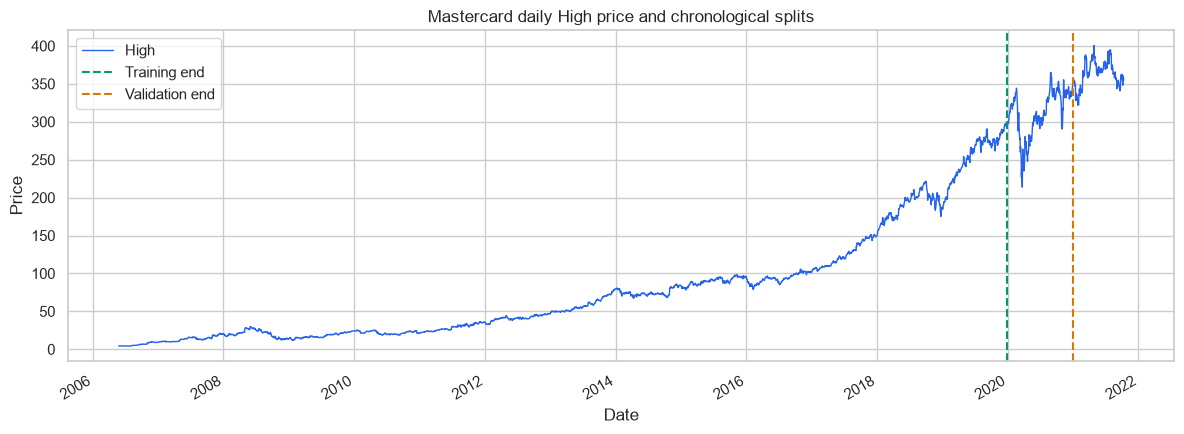

In [3]:
fig, axis = plt.subplots(figsize=(12, 4.5))
stock_history[TARGET_COLUMN].plot(ax=axis, color="#2563eb", linewidth=1)
axis.axvline(TRAIN_END, color="#059669", linestyle="--", label="Training end")
axis.axvline(VALIDATION_END, color="#d97706", linestyle="--", label="Validation end")
axis.set(
    title="Mastercard daily High price and chronological splits",
    xlabel="Date",
    ylabel="Price",
)
axis.legend()
plt.tight_layout()
plt.show()

## 2. Scale the Training Period and Build 60-Day Sequences

In [4]:
target_series = stock_history[TARGET_COLUMN].astype("float32")
training_values = target_series.loc[:TRAIN_END].to_numpy().reshape(-1, 1)

scaler = MinMaxScaler()
scaler.fit(training_values)
scaled_values = scaler.transform(target_series.to_numpy().reshape(-1, 1)).astype("float32")


def make_sequences(values: np.ndarray, dates: pd.DatetimeIndex, lookback: int):
    features, targets, target_dates = [], [], []
    for target_index in range(lookback, len(values)):
        features.append(values[target_index - lookback : target_index])
        targets.append(values[target_index])
        target_dates.append(dates[target_index])
    return (
        np.asarray(features, dtype="float32"),
        np.asarray(targets, dtype="float32"),
        pd.DatetimeIndex(target_dates),
    )


sequence_features, sequence_targets, sequence_dates = make_sequences(
    scaled_values,
    target_series.index,
    LOOKBACK_DAYS,
)

training_mask = sequence_dates <= TRAIN_END
validation_mask = (sequence_dates > TRAIN_END) & (sequence_dates <= VALIDATION_END)
test_mask = sequence_dates > VALIDATION_END

X_train, y_train = sequence_features[training_mask], sequence_targets[training_mask]
X_validation, y_validation = (
    sequence_features[validation_mask],
    sequence_targets[validation_mask],
)
X_test, y_test = sequence_features[test_mask], sequence_targets[test_mask]

validation_dates = sequence_dates[validation_mask]
test_dates = sequence_dates[test_mask]

assert len(X_train) > 0 and len(X_validation) > 0 and len(X_test) > 0
assert X_train.shape[1:] == (LOOKBACK_DAYS, 1)
assert test_dates.min().year == 2021

split_summary = pd.DataFrame(
    {
        "period": ["Training", "Validation", "Test"],
        "target_start": [
            sequence_dates[training_mask].min().date().isoformat(),
            validation_dates.min().date().isoformat(),
            test_dates.min().date().isoformat(),
        ],
        "target_end": [
            sequence_dates[training_mask].max().date().isoformat(),
            validation_dates.max().date().isoformat(),
            test_dates.max().date().isoformat(),
        ],
        "sequences": [len(X_train), len(X_validation), len(X_test)],
    }
)
split_summary

,period,target_start,target_end,sequences
0,Training,2006-08-21,2019-12-31,3364
1,Validation,2020-01-02,2020-12-31,253
2,Test,2021-01-04,2021-10-11,195


## 3. Define the Baseline and Evaluation Metrics

In [5]:
test_actual = scaler.inverse_transform(y_test).ravel()
test_previous = target_series.shift(1).loc[test_dates].to_numpy()


def evaluate_forecast(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict:
    actual = np.asarray(actual).ravel()
    predicted = np.asarray(predicted).ravel()
    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "MAPE (%)": float(np.mean(np.abs((actual - predicted) / actual)) * 100),
    }


baseline_metrics = evaluate_forecast(test_actual, test_previous)
pd.Series(baseline_metrics, name="Persistence baseline")

RMSE        5.2765
MAE         3.8446
MAPE (%)    1.0577
Name: Persistence baseline, dtype: float64

## 4. Train LSTM and GRU Models

In [6]:
def build_recurrent_model(cell_type: str) -> keras.Sequential:
    keras.utils.set_random_seed(RANDOM_STATE)
    recurrent_layer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[cell_type]
    model = keras.Sequential(
        [
            keras.Input(shape=(LOOKBACK_DAYS, 1)),
            recurrent_layer(32, activation="tanh"),
            layers.Dropout(0.10),
            layers.Dense(1),
        ],
        name=f"{cell_type.lower()}_stock_forecaster",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def train_model(model: keras.Sequential):
    return model.fit(
        X_train,
        y_train,
        validation_data=(X_validation, y_validation),
        epochs=30,
        batch_size=64,
        shuffle=False,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=4,
                min_delta=1e-5,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                patience=2,
                factor=0.5,
                min_lr=1e-5,
            ),
        ],
        verbose=2,
    )

In [7]:
lstm_model = build_recurrent_model("LSTM")
lstm_history = train_model(lstm_model)
print("LSTM trainable parameters:", lstm_model.count_params())

Epoch 1/30


53/53 - 1s - 21ms/step - loss: 0.0043 - mae: 0.0473 - val_loss: 0.0076 - val_mae: 0.0696 - learning_rate: 0.0010


Epoch 2/30


53/53 - 0s - 7ms/step - loss: 0.0360 - mae: 0.1595 - val_loss: 0.0185 - val_mae: 0.1251 - learning_rate: 0.0010


Epoch 3/30


...

Epoch 7/30


53/53 - 0s - 8ms/step - loss: 9.5887e-04 - mae: 0.0187 - val_loss: 0.0025 - val_mae: 0.0378 - learning_rate: 2.5000e-04


Epoch 8/30


53/53 - 0s - 7ms/step - loss: 8.7222e-04 - mae: 0.0188 - val_loss: 0.0025 - val_mae: 0.0369 - learning_rate: 2.5000e-04


LSTM trainable parameters: 4385


In [8]:
gru_model = build_recurrent_model("GRU")
gru_history = train_model(gru_model)
print("GRU trainable parameters:", gru_model.count_params())

Epoch 1/30


53/53 - 1s - 23ms/step - loss: 0.0050 - mae: 0.0532 - val_loss: 0.0052 - val_mae: 0.0605 - learning_rate: 0.0010


Epoch 2/30


53/53 - 0s - 9ms/step - loss: 0.0548 - mae: 0.1927 - val_loss: 0.0352 - val_mae: 0.1813 - learning_rate: 0.0010


Epoch 3/30


...

Epoch 6/30


53/53 - 0s - 9ms/step - loss: 9.6596e-04 - mae: 0.0205 - val_loss: 0.0015 - val_mae: 0.0301 - learning_rate: 5.0000e-04


Epoch 7/30


53/53 - 0s - 9ms/step - loss: 7.9094e-04 - mae: 0.0174 - val_loss: 0.0015 - val_mae: 0.0297 - learning_rate: 5.0000e-04


GRU trainable parameters: 3393


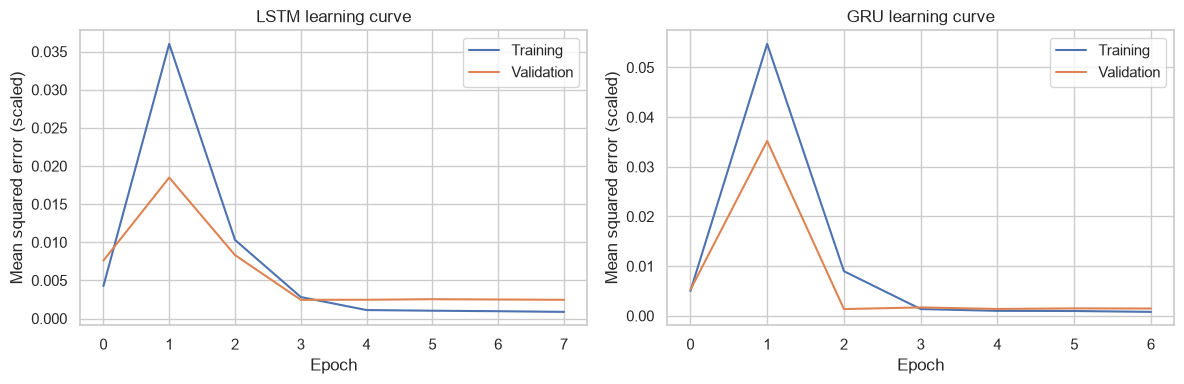

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, history, title in zip(
    axes,
    [lstm_history, gru_history],
    ["LSTM", "GRU"],
):
    axis.plot(history.history["loss"], label="Training")
    axis.plot(history.history["val_loss"], label="Validation")
    axis.set(
        title=f"{title} learning curve",
        xlabel="Epoch",
        ylabel="Mean squared error (scaled)",
    )
    axis.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate on the Untouched 2021 Test Period

In [10]:
lstm_predictions = scaler.inverse_transform(
    lstm_model.predict(X_test, batch_size=128, verbose=0)
).ravel()
gru_predictions = scaler.inverse_transform(
    gru_model.predict(X_test, batch_size=128, verbose=0)
).ravel()

lstm_metrics = evaluate_forecast(test_actual, lstm_predictions)
gru_metrics = evaluate_forecast(test_actual, gru_predictions)

metrics_table = (
    pd.DataFrame(
        {
            "Persistence baseline": baseline_metrics,
            "LSTM": lstm_metrics,
            "GRU": gru_metrics,
        }
    )
    .T
    .sort_values("RMSE")
)

assert len(test_actual) == len(test_dates) == 195
assert np.isfinite(metrics_table.to_numpy()).all()

display(metrics_table.round(3))
print(
    "PORTFOLIO_METRICS_JSON="
    + json.dumps(
        {
            model: {metric: round(float(value), 6) for metric, value in row.items()}
            for model, row in metrics_table.iterrows()
        },
        sort_keys=True,
    )
)

,RMSE,MAE,MAPE (%)
Persistence baseline,5.276,3.845,1.058
GRU,7.473,5.872,1.617
LSTM,11.475,9.489,2.588


PORTFOLIO_METRICS_JSON={"GRU": {"MAE": 5.871664, "MAPE (%)": 1.616683, "RMSE": 7.47261}, "LSTM": {"MAE": 9.489427, "MAPE (%)": 2.587656, "RMSE": 11.474812}, "Persistence baseline": {"MAE": 3.844611, "MAPE (%)": 1.057684, "RMSE": 5.276461}}


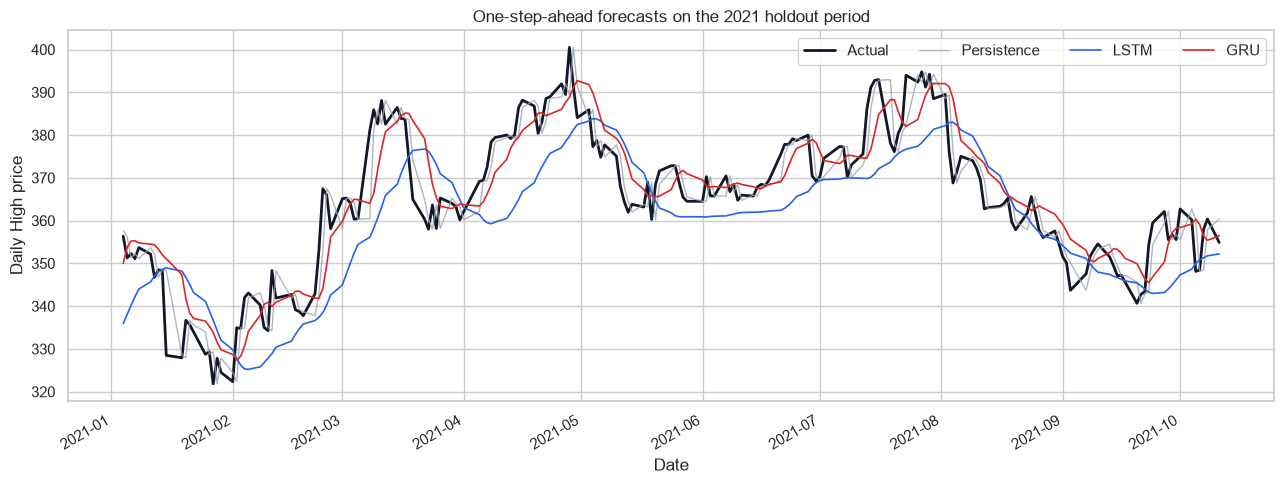

In [11]:
forecast_frame = pd.DataFrame(
    {
        "Actual": test_actual,
        "Persistence baseline": test_previous,
        "LSTM": lstm_predictions,
        "GRU": gru_predictions,
    },
    index=test_dates,
)

fig, axis = plt.subplots(figsize=(13, 5))
forecast_frame["Actual"].plot(ax=axis, color="#111827", linewidth=2, label="Actual")
forecast_frame["Persistence baseline"].plot(
    ax=axis, color="#9ca3af", linewidth=1, alpha=0.8, label="Persistence"
)
forecast_frame["LSTM"].plot(ax=axis, color="#2563eb", linewidth=1.2, label="LSTM")
forecast_frame["GRU"].plot(ax=axis, color="#dc2626", linewidth=1.2, label="GRU")
axis.set(
    title="One-step-ahead forecasts on the 2021 holdout period",
    xlabel="Date",
    ylabel="Daily High price",
)
axis.legend(ncol=4)
plt.tight_layout()
plt.show()

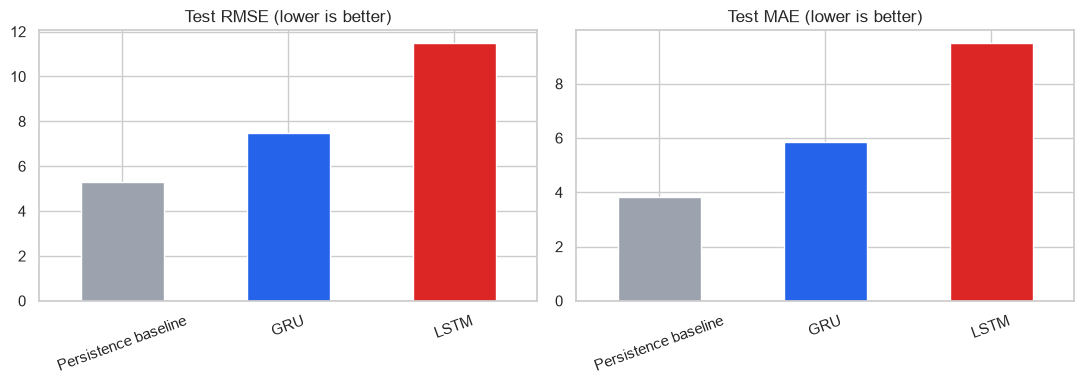

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metric_colours = ["#9ca3af", "#2563eb", "#dc2626"]
metrics_table["RMSE"].plot.bar(
    ax=axes[0],
    color=metric_colours,
    title="Test RMSE (lower is better)",
)
metrics_table["MAE"].plot.bar(
    ax=axes[1],
    color=metric_colours,
    title="Test MAE (lower is better)",
)
for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## Results Summary

The persistence baseline ranked first on the untouched 2021 test period with
**5.28 RMSE** and **3.84 MAE**. GRU was the stronger
neural model at **7.47 RMSE**, followed by LSTM at
**11.47 RMSE**.

The result does not support claiming that either recurrent model adds forecasting value over
the previous observed price for this setup. Because the experiment predicts price levels
rather than returns, even low error would not imply a profitable trading signal.


## Takeaways

1. **Chronological evaluation is essential.** Random train/test splitting would allow future
   price patterns to leak into training.
2. **A strong naive baseline changes the interpretation.** Smooth-looking neural-network
   forecasts are not sufficient; LSTM and GRU must outperform the previous-day price.
3. **The forecast horizon is deliberately narrow.** These are one-step-ahead estimates using
   observed history, not recursive forecasts of an unknown future path.
4. **Model error is not investment performance.** No fees, execution, risk, or trading rules
   are modelled.

### Limitations and next steps

- Results come from one security, one target variable, one historical period, and one seeded
  run.
- Price levels are non-stationary; future work should compare return-based targets and
  rolling-origin cross-validation.
- Hyperparameter tuning, exogenous features, uncertainty intervals, regime shifts, and
  transaction costs are outside this activity's scope.
- The historical dataset ends in October 2021, so the notebook is a retrospective learning
  exercise rather than a current market forecast.